In [3]:
!pip install -U ultralytics roboflow supervision opencv-python matplotlib pandas pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 95.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.0 MB/s eta 0:00:0000:01
   ━━━━━━━━

In [4]:
import os
import yaml
import shutil
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from roboflow import Roboflow
from pathlib import Path

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key="BxGuDSFAaaOV0Kxq9HH4")
project = rf.workspace("ahmed-mohsen-on9f0").project("cv-bonus-project-v1-5-4")
version = project.version(4)
dataset = version.download("yolo26")

DATASET_DIR = dataset.location
print("Dataset downloaded to:", DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to CV-bonus-project-v1-5/4-4 in yolo26:: 100%|██████████| 5771/5771 [00:00<00:00, 10705.76it/s]

Dataset downloaded to: /kaggle/working/CV-bonus-project-v1-5/4-4


In [7]:
!find {DATASET_DIR} -maxdepth 3 -type f | head -50

/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_141037_idx00387_jpg.rf.9c6c178e84f24dfcf6819307e9ae0613.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_140731_idx00054_jpg.rf.93aed65e572735195cd811abb40169a5.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_135854_idx00330_jpg.rf.0e5184bd114a45bb104dfee8f6781d72.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_140453_idx00267_jpg.rf.d8a97c8b9adec61900e4bbed44c87a52.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/IMG_20260504_144148_jpg.rf.c3a71ce33b1a722d35382d92b9935ece.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_135512_idx00213_jpg.rf.d5c5063a0d20caef74e0353e30304ccd.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_143732_idx00105_jpg.rf.33dfb46569612233e3e6272eceeb7e19.jpg
/kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_142218_idx00636_jpg.rf.d8ee1590924b1f5419a2cd2d5ea60b

In [8]:
data_yaml_path = os.path.join(DATASET_DIR, "data.yaml")

with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['ball', 'car', 'fallen-pins', 'standing-pins'], 'roboflow': {'workspace': 'ahmed-mohsen-on9f0', 'project': 'cv-bonus-project-v1-5-4', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ahmed-mohsen-on9f0/cv-bonus-project-v1-5-4/dataset/4'}}


In [9]:
expected_classes = ["ball", "car", "fallen-pins", "standing-pins"]

print("Dataset classes:", data_yaml.get("names"))

assert data_yaml.get("names") == expected_classes or set(data_yaml.get("names", [])) == set(expected_classes), \
    "Class names do not match expected classes. Check Roboflow export."

Dataset classes: ['ball', 'car', 'fallen-pins', 'standing-pins']


In [10]:
data_yaml["path"] = DATASET_DIR
data_yaml["train"] = "train/images"
data_yaml["val"] = "valid/images"
data_yaml["test"] = "test/images"

with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print(open(data_yaml_path).read())

names:
- ball
- car
- fallen-pins
- standing-pins
nc: 4
path: /kaggle/working/CV-bonus-project-v1-5/4-4
roboflow:
  license: CC BY 4.0
  project: cv-bonus-project-v1-5-4
  url: https://universe.roboflow.com/ahmed-mohsen-on9f0/cv-bonus-project-v1-5-4/dataset/4
  version: 4
  workspace: ahmed-mohsen-on9f0
test: test/images
train: train/images
val: valid/images



In [11]:
def count_labels(label_dir):
    label_dir = Path(label_dir)
    counts = {}
    total_boxes = 0

    for txt in label_dir.glob("*.txt"):
        with open(txt, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
        for line in lines:
            cls = int(line.split()[0])
            counts[cls] = counts.get(cls, 0) + 1
            total_boxes += 1

    return counts, total_boxes

names = data_yaml["names"]

for split in ["train", "valid", "test"]:
    label_dir = os.path.join(DATASET_DIR, split, "labels")
    counts, total = count_labels(label_dir)

    print(f"\n{split.upper()} total boxes:", total)
    for cls_id, count in sorted(counts.items()):
        print(f"{cls_id} - {names[cls_id]}: {count}")


TRAIN total boxes: 29159
0 - ball: 2323
1 - car: 1828
2 - fallen-pins: 8327
3 - standing-pins: 16681

VALID total boxes: 3045
0 - ball: 210
1 - car: 177
2 - fallen-pins: 896
3 - standing-pins: 1762

TEST total boxes: 1336
0 - ball: 112
1 - car: 78
2 - fallen-pins: 404
3 - standing-pins: 742


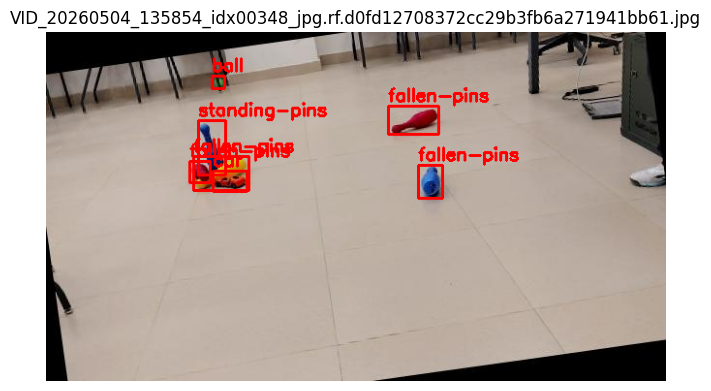

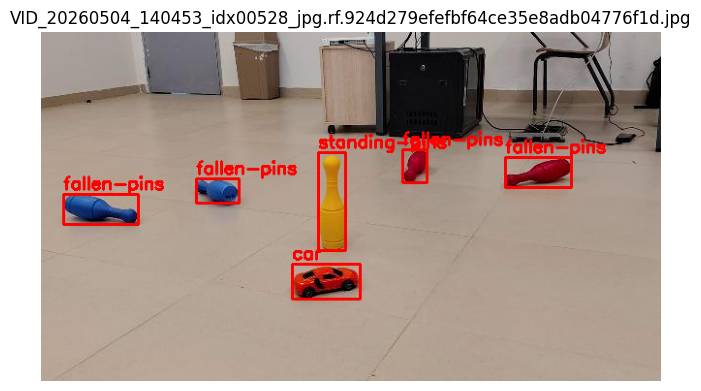

In [ ]:
def draw_yolo_labels(image_path, label_path, names):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            cls = int(parts[0])
            x, y, bw, bh = map(float, parts[1:5])

            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, names[cls], (x1, max(20, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return img

image_dir = Path(DATASET_DIR) / "train" / "images"
label_dir = Path(DATASET_DIR) / "train" / "labels"

sample_images = random.sample(list(image_dir.glob("*")), min(6, len(list(image_dir.glob("*")))))

for img_path in sample_images:
    label_path = label_dir / (img_path.stem + ".txt")
    img = draw_yolo_labels(img_path, label_path, names)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

In [14]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,

    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    patience=25,
    cos_lr=True,

    project="/kaggle/working/runs",
    name="rc_bowling_yolo26n_no_extra_aug",
    exist_ok=True
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/CV-bonus-project-v1-5/4-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rc_bowling_yolo26n_no_extra_aug, nbs=64, nms=False, opset=None, optimize=False, opt

In [16]:
BEST_MODEL = "/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best.pt"

model = YOLO(BEST_MODEL)

metrics = model.val(
    data=data_yaml_path,
    split="val",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0
)

print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 660.1±118.6 MB/s, size: 19.1 KB)
val: Scanning /kaggle/working/CV-bonus-project-v1-5/4-4/valid/labels.cache... 240 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 100.7Mit/s 0.0s
val: /kaggle/working/CV-bonus-project-v1-5/4-4/valid/images/VID_20260504_135512_idx00021_jpg.rf.f7b7bda8803f1b56ad2bb9df8e995517.jpg: 5 duplicate labels removed
val: /kaggle/working/CV-bonus-project-v1-5/4-4/valid/images/VID_20260504_135512_idx00279_jpg.rf.bf918a05d125e12a82abfe551e711014.jpg: 8 duplicate labels removed
val: /kaggle/working/CV-bonus-project-v1-5/4-4/valid/images/VID_20260504_135512_idx00591_jpg.rf.fc692649cb4d0b496d1c734cc3a8fe60.jpg: 8 duplicate labels removed
val: /kaggle/working/CV-bonus-project-v1-5/4-4/valid/images/VID_20260504_135512_idx00678_jpg.rf.17b748e6d93123

In [19]:
test_metrics = model.val(
    data=data_yaml_path,
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0
)

print(test_metrics)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 580.8±187.3 MB/s, size: 19.6 KB)
val: Scanning /kaggle/working/CV-bonus-project-v1-5/4-4/test/labels.cache... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 50.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.2it/s 2.5s0.2s
                   all        120       1336       0.78      0.745      0.762      0.444
                  ball         63        112      0.701      0.705      0.686       0.32
                   car         77         78      0.681      0.821      0.807      0.418
           fallen-pins        104        404      0.788      0.653      0.674      0.431
         standing-pins        114        742      0.952        0.8      0.879      0.606
Speed: 1.9ms preprocess, 6.6ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /kagg

In [25]:
TEST_IMAGE_DIR = os.path.join(DATASET_DIR, "test/images")

pred_results = model.predict(
    source=TEST_IMAGE_DIR,
    imgsz=640,
    conf=0.20,
    iou=0.45,
    save=True,
    project="/kaggle/working/predictions",
    name="test_predictions",
    exist_ok=True
)

print("Saved predictions to /kaggle/working/predictions/test_predictions")


image 1/120 /kaggle/working/CV-bonus-project-v1-5/4-4/test/images/IMG_20260504_144148_jpg.rf.c3a71ce33b1a722d35382d92b9935ece.jpg: 480x640 1 fallen-pins, 24 standing-pinss, 14.2ms
image 2/120 /kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_135512_idx00063_jpg.rf.19e891350a468f63167b5fd90e0bbaad.jpg: 384x640 2 balls, 1 car, 2 fallen-pinss, 6 standing-pinss, 10.1ms
image 3/120 /kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_135512_idx00156_jpg.rf.222ecc0bbcaea0dd844d6497ae5d6836.jpg: 384x640 2 balls, 2 cars, 2 fallen-pinss, 10 standing-pinss, 9.7ms
image 4/120 /kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_135512_idx00213_jpg.rf.d5c5063a0d20caef74e0353e30304ccd.jpg: 384x640 2 balls, 1 car, 3 fallen-pinss, 8 standing-pinss, 10.4ms
image 5/120 /kaggle/working/CV-bonus-project-v1-5/4-4/test/images/VID_20260504_135512_idx00306_jpg.rf.41edd4efc275a1647f04687654459711.jpg: 384x640 3 balls, 2 cars, 2 fallen-pinss, 10 standing-pinss, 10.

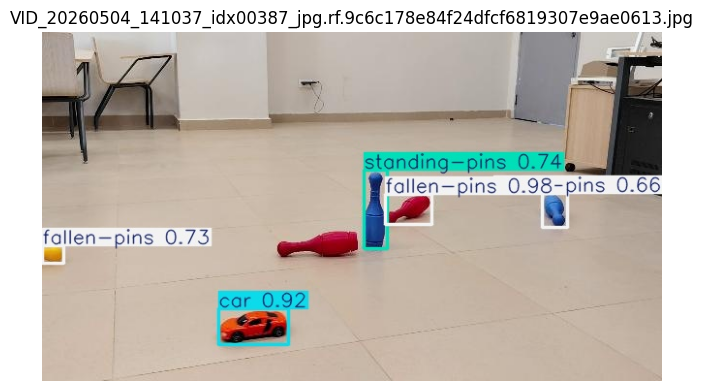

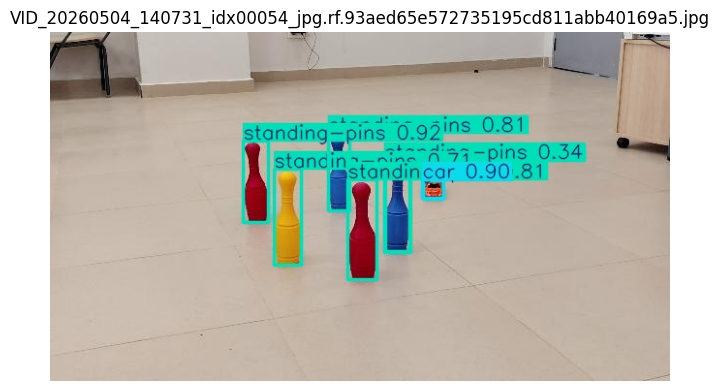

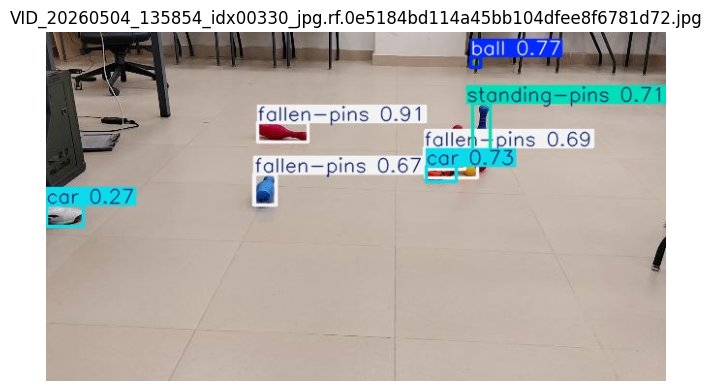

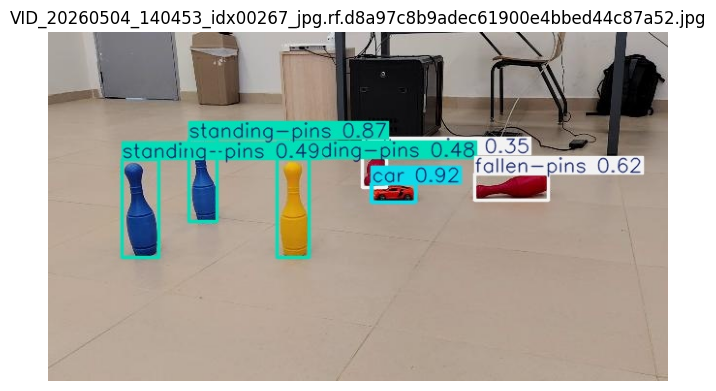

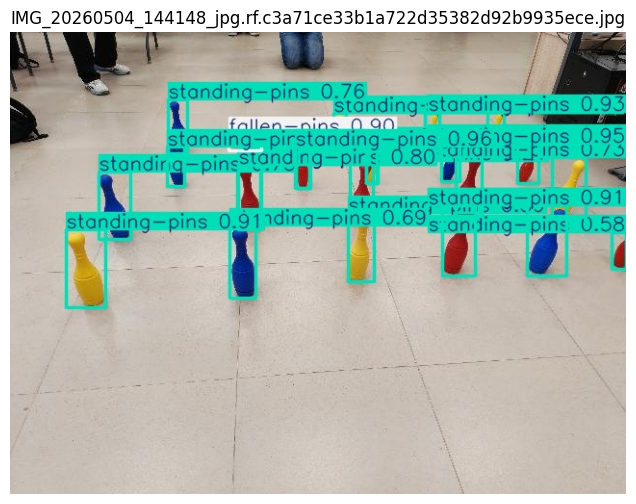

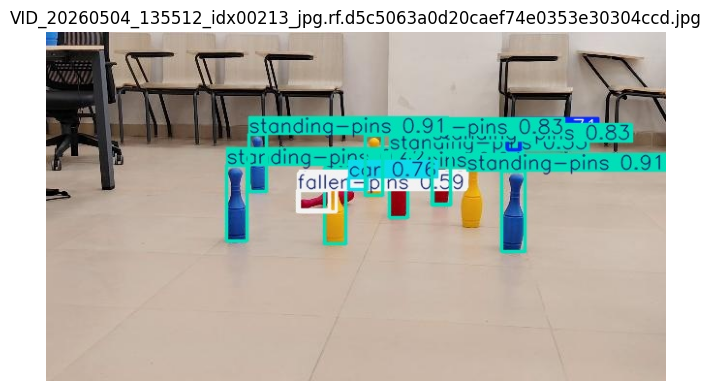

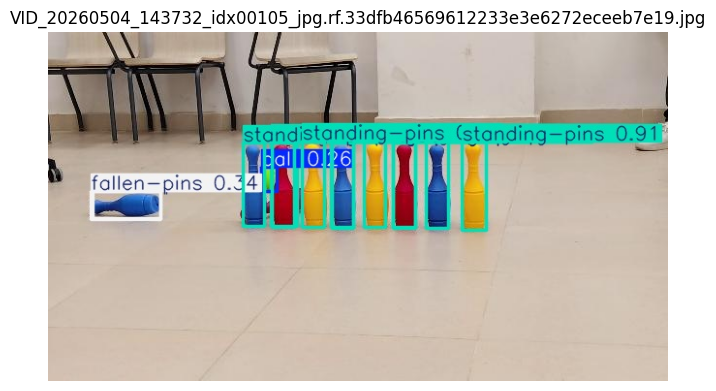

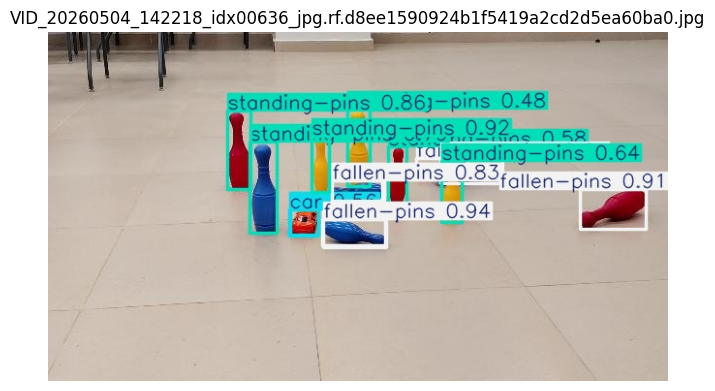

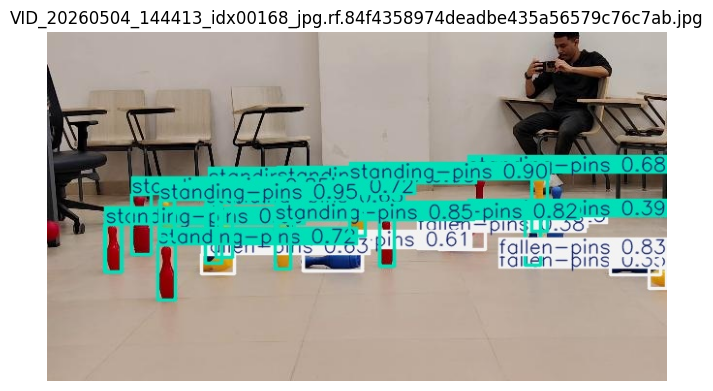

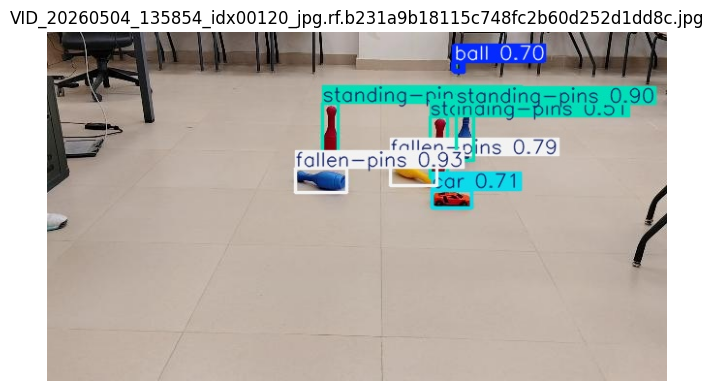

In [26]:
pred_dir = Path("/kaggle/working/predictions/test_predictions")
pred_imgs = list(pred_dir.glob("*"))

for img_path in pred_imgs[:10]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

In [28]:
model = YOLO(BEST_MODEL)

model.export(
    format="tflite",
    imgsz=640,
    int8=False,
    half=False,
    nms=True
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ 'nms=True' is not available for end2end models. Forcing 'nms=False'.
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.8 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 2.5s, saved as '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best.onnx' (9.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf

I0000 00:00:1777992337.917830      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1777992337.918007      57 single_machine.cc:374] Starting new session
I0000 00:00:1777992337.925578      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12889 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
W0000 00:00:1777992338.950788      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777992338.950830      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777992339.745913      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1777992339.746098      57 single_machine.cc:374] Starting new session
I0000 00:00:1777992339.753570      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12889 MB memory:  -> device: 0, name: Tesl

TensorFlow SavedModel: export success ✅ 21.1s, saved as '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model' (23.7 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model/best_float32.tflite' (9.4 MB)

Export complete (21.5s)
Results saved to /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model/best_float32.tflite
Predict:         yolo predict task=detect model=/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model/best_float32.tflite imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model/best_float32.tflite imgsz=640 data=/kaggle/working/CV-bonus-project-v1-5/4-4/data.yaml  
Visualize:       https://netron.app


'/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_saved_model/best_float32.tflite'

In [29]:
model = YOLO(BEST_MODEL)

model.export(
    format="tflite",
    imgsz=640,
    int8=True,
    data=data_yaml_path,
    nms=True
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ 'nms=True' is not available for end2end models. Forcing 'nms=False'.
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.8 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/kaggle/working/CV-bonus-project-v1-5/4-4/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 737.8±205.5 MB/s, size: 21.8 KB)
Scanning /kaggle/working/CV-bonus-project-v1-5/4-4/valid/labels.cache... 240 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 83.9Mit/s 0.0s
val: /kaggle/working/CV-bonus-project-v1-5/4-4/valid/images/VID_20260504_135512_idx00021_jpg.rf.f7b7bda8803f1b56ad2bb9df8e995517.jpg: 5 duplicate labels removed
val: /kaggle/working/CV-bonus-project-v1-5/4-4/valid/images/VID_20

I0000 00:00:1777992496.788930      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1777992496.789102      57 single_machine.cc:374] Starting new session
I0000 00:00:1777992496.798215      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12889 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
W0000 00:00:1777992497.878013      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777992497.878047      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777992498.655261      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1777992498.655451      57 single_machine.cc:374] Starting new session
I0000 00:00:1777992498.663097      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12889 MB memory:  -> device: 0, name: Tesl

W0000 00:00:1777992505.526017      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777992505.526048      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777992505.571956      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777992766.351048      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777992766.351118      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777993025.015799      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777993025.015860      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777993540.551481      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_for

KeyboardInterrupt: 

In [30]:
model = YOLO(BEST_MODEL)

model.export(
    format="ncnn",
    imgsz=640
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
YOLO26n summary (fused): 146 layers, 2,495,864 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (19.8 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 1 package in 85ms
Prepared 1 package in 168ms
Installed 1 package in 2ms
 + ncnn==1.0.20260114

requirements: AutoUpdate success ✅ 0.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 29 packages in 227ms
Prepared 1 package in 365ms
Installed 1 package in 3ms
 + pnnx==2

pnnxparam = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model.pnnx.param
pnnxbin = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model.pnnx.bin
pnnxpy = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model_pnnx.py
pnnxonnx = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model.pnnx.onnx
ncnnparam = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model.ncnn.param
ncnnbin = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model.ncnn.bin
ncnnpy = /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model/model_ncnn.py
fp16 = 0
optlevel = 2
device = cpu
inputshape = [1,3,640,640]f32
inputshape2 = 
customop = 
moduleop = 
get inputshape from traced inputs
inputshape = [1,3,640,640]f32
############# pass_level0
inline module = torch.nn.modules.linear.Identity
inline module = ultralytics.nn.modules.block.Attention
inline mod

NCNN: export success ✅ 5.9s, saved as '/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model' (9.3 MB)

Export complete (6.3s)
Results saved to /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model
Predict:         yolo predict task=detect model=/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model imgsz=640 data=/kaggle/working/CV-bonus-project-v1-5/4-4/data.yaml  
Visualize:       https://netron.app


'/kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best_ncnn_model'

In [31]:
model = YOLO(BEST_MODEL)

benchmark_results = model.benchmark(
    data=data_yaml_path,
    imgsz=640,
    device=0,
    half=False,
    int8=True
)

print(benchmark_results)

Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6849.2/8062.4 GB disk)

Benchmarks complete for /kaggle/working/runs/rc_bowling_yolo26n_transfer/weights/best.pt on /kaggle/working/CV-bonus-project-v1-5/4-4/data.yaml at imgsz=640 (173.81s)
Benchmarks legend:  - ✅ Success  - ❎ Export passed but validation failed  - ❌️ Export failed
+----------------------------------------------------------------------------------------------------------+
|      Format                  Status❔   Size (MB)   metrics/mAP50-95(B)   Inference time (ms/im)   FPS   |
+==========================================================================================================+
| 1    PyTorch                 ✅         19.8        0.6013                12.38                    80.75 |
| 2    TorchScript             ❌         0.0         -                     -                        -     |
| 3    ONNX                    ❌         0.0         -                     -                        -     |
| 4    OpenVINO            